In [ ]:
# Third-party numerical libraries
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Notebook interface
import marimo as mo

# Developer notebook: From a bespoke interface to a common interface

## Introduction

This notebook demonstrates how a developer can extend CoFI with a new inference tool. CoFI's plugin architecture is designed so that adding a solver only requires implementing a single class that conforms to a well-defined interface. Once registered, the new solver becomes available to every CoFI user through the same three-class workflow (`BaseProblem`, `InversionOptions`, `Inversion`) used throughout the framework.

### Why Contribute a Solver?

- **Access to a rich library of examples.** CoFI ships with a diverse collection of geoscience inverse problems. By contributing a solver, the method can immediately be tested against all of these examples without building test cases from scratch.

- **Wider reach with minimal friction.** Once registered as a CoFI backend, a solver becomes available to any researcher who has already defined their inverse problem in CoFI. Users can switch to any method by changing a single option in `InversionOptions`, with no need to learn a tool's native API.

- **Standardised benchmarking and comparison.** Because every solver operates on the same `BaseProblem` definition, users can rigorously compare  methods against existing solvers on identical problems. This lowers the barrier to reproducible comparison in publications and teaching materials.

### What This Notebook Builds

This notebook walks through the process of integrating the **Slime Mould Algorithm** (SMA; Li et al., 2020) into CoFI. SMA is a bio-inspired, gradient-free metaheuristic that simulates the foraging behaviour of slime mould (*Physarum polycephalum*). It is particularly effective on multimodal objective landscapes where gradient-based methods become trapped in local minima.

The implementation uses the [MEALPY](https://github.com/thieu1995/mealpy) library, which provides a mature, well-tested implementation of SMA along with dozens of other metaheuristic optimizers.

> **Note:** A production MEALPY-SMA solver already ships with CoFI (registered as `mealpy.sma`). This notebook re-implements it from scratch under the name `mealpy.sma.demo.from.this.notebook` purely to illustrate the contribution process step by step. The patterns shown here apply to any new solver.

### Notebook Overview

1. **Motivation** — A multimodal test problem where gradient-based optimisation fails
2. **The `BaseInferenceTool` contract** — What CoFI requires from a solver
3. **Implementation** — Building the SMA tool class step by step
4. **Registration** — Making the tool available through CoFI's API
5. **Validation** — Testing the tool on the motivating problem
6. **Define once, solve many ways** — Comparing SMA against existing solvers
7. **Contribution checklist** — What a pull request should contain

## 1. Motivation: When Gradient-Based Methods Fail

The **Himmelblau function** is a classic test problem with four global minima of equal depth:

$$f(x_1, x_2) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$$

The four minima are located at approximately:

| $x_1$ | $x_2$ | $f(x_1, x_2)$ |
|-------|-------|----------------|
| 3.0 | 2.0 | 0.0 |
| −2.805 | 3.131 | 0.0 |
| −3.779 | −3.283 | 0.0 |
| 3.584 | −1.848 | 0.0 |

A gradient-based optimizer will converge to whichever minimum is nearest to the starting point. It cannot explore the landscape to discover all four. Let us see this in action.

In [ ]:
def himmelblau(model):
    """Modified Himmelblau function. Accepts a 2D model vector."""
    x1, x2 = model
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

def himmelblau_gradient(model):
    """Gradient of the Himmelblau function."""
    x1, x2 = model
    df_dx1 = 4*x1*(x1**2 + x2 - 11) + 2*(x1 + x2**2 - 7)
    df_dx2 = 2*(x1**2 + x2 - 11) + 4*x2*(x1 + x2**2 - 7)
    return np.array([df_dx1, df_dx2])

# Known global minima
himmelblau_minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126],
])

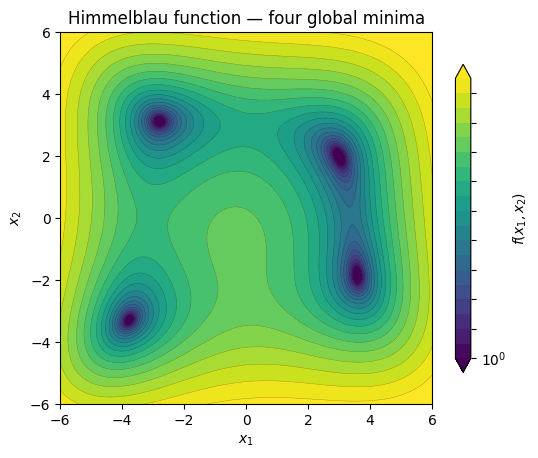

In [ ]:
def plot_himmelblau_landscape(ax=None, title=None):
    """Plot the Himmelblau function as a filled contour."""
    x = np.linspace(-6, 6, 300)
    y = np.linspace(-6, 6, 300)
    X, Y = np.meshgrid(x, y)
    Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    levels = np.logspace(0, 3, 20)
    cs = ax.contourf(
        X, Y, Z, levels=levels,
        norm=mcolors.LogNorm(vmin=1, vmax=1000),
        cmap="viridis", extend="both",
    )
    ax.contour(X, Y, Z, levels=levels, colors="k", linewidths=0.3, alpha=0.4)
    plt.colorbar(cs, ax=ax, label="$f(x_1, x_2)$", shrink=0.8)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    return ax

plot_himmelblau_landscape(title="Himmelblau function — four global minima")

### Gradient-based optimisation with `scipy.optimize.minimize`

Let us attempt to find the global minima using CoFI's `scipy.optimize.minimize` backend from several starting points. Each run will converge to the nearest local (which happens to be global) minimum — but no single run explores the full landscape.

In [ ]:
from cofi import BaseProblem, InversionOptions, Inversion

In [ ]:
# Run scipy from 4 different starting points
scipy_starts = [
    np.array([1.0, 1.0]),
    np.array([-1.0, 4.0]),
    np.array([-4.0, -2.0]),
    np.array([4.0, -3.0]),
]
scipy_results = []
for _start in scipy_starts:
    _prob = BaseProblem()
    _prob.set_objective(himmelblau)
    _prob.set_gradient(himmelblau_gradient)
    _prob.set_initial_model(_start)
    _prob.set_model_shape((2,))

    _opts = InversionOptions()
    _opts.set_solving_method("optimization")
    _opts.set_tool("scipy.optimize.minimize")

    _res = Inversion(_prob, _opts).run()
    scipy_results.append(_res)
    print(f"Start {_start} → minimum at [{_res.model[0]:7.3f}, {_res.model[1]:7.3f}],"
          f"  f = {himmelblau(_res.model):.2e}")

Start [1. 1.] → minimum at [  3.000,   2.000],  f = 2.10e-17
Start [-1.  4.] → minimum at [ -2.805,   3.131],  f = 4.47e-13
Start [-4. -2.] → minimum at [ -3.779,  -3.283],  f = 2.09e-16
Start [ 4. -3.] → minimum at [  3.584,  -1.848],  f = 7.65e-19


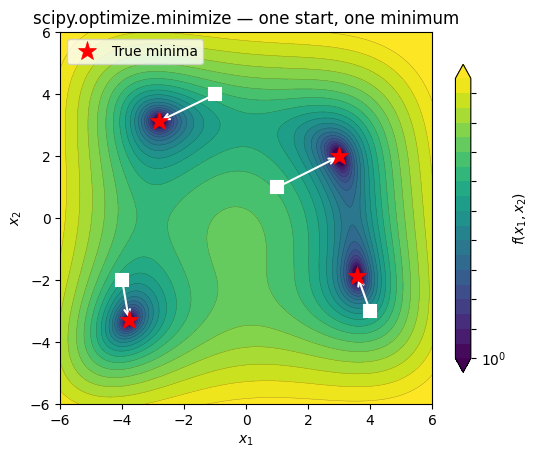

In [ ]:
fig_scipy, ax_scipy = plt.subplots(figsize=(6, 5))
plot_himmelblau_landscape(ax=ax_scipy, title="scipy.optimize.minimize — one start, one minimum")

for _start, _res in zip(scipy_starts, scipy_results):
    ax_scipy.plot(*_start, "ws", ms=8, mew=1.5, zorder=5)
    ax_scipy.annotate(
        "", xy=_res.model, xytext=_start,
        arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    )

ax_scipy.plot(*himmelblau_minima.T, "r*", ms=14, mew=0.5, label="True minima", zorder=6)
ax_scipy.legend(loc="upper left")
fig_scipy

White squares show the starting points for the local optimizer, and arrows indicate convergence to the nearest minimum. To find all four minima, four separate runs with carefully chosen starting points were needed. A population-based metaheuristic like SMA can explore the full landscape in a single run.

**This is the motivation**: making SMA available in CoFI so that any user can access it through the standard API. Let us now see what CoFI requires from a new solver.

## 2. The `BaseInferenceTool` Contract

Every solver in CoFI is a subclass of `BaseInferenceTool`. The contract is straightforward — implement six members:

| Member | Type | Purpose |
|--------|------|---------|
| `required_in_problem()` | classmethod → `set` | Problem components the solver **must** have (e.g. `{"objective", "model_shape"}`) |
| `optional_in_problem()` | classmethod → `dict` | Components the solver **can** use, with defaults (e.g. `{"bounds": None}`) |
| `required_in_options()` | classmethod → `set` | Solver parameters the user **must** provide |
| `optional_in_options()` | classmethod → `dict` | Solver parameters with sensible defaults (e.g. `{"epoch": 100}`) |
| `__init__(problem, options)` | method | Validation and setup (call `super().__init__()` to get automatic checks) |
| `__call__()` | method | Run the solver; return a dict with `"model"` and `"success"` |

The base class handles validation automatically: if a required component is missing, CoFI raises a clear error before the solver ever runs. Optional components fall back to defaults.

### Key design principle

Solvers operate on **flat parameter vectors**. They know nothing about the physics of the problem — no coordinate systems, no spatial structure, no units. This separation is what makes CoFI's "define once, solve many ways" philosophy work: the problem definition contains the physics, the solver contains the algorithm.

Let us inspect an existing tool to see the pattern in practice.

In [ ]:
from cofi.tools import BaseInferenceTool

In [ ]:
# Inspect an existing tool — CoFI's simple Newton solver
from cofi.tools._cofi_simple_newton import CoFISimpleNewton

print("required_in_problem:", CoFISimpleNewton.required_in_problem())
print("optional_in_problem:", CoFISimpleNewton.optional_in_problem())
print("required_in_options:", CoFISimpleNewton.required_in_options())
print("optional_in_options:", CoFISimpleNewton.optional_in_options())

required_in_problem: {'initial_model', 'hessian', 'gradient', 'objective'}
optional_in_problem: {}
required_in_options: {'num_iterations'}
optional_in_options: {'step_length': 1, 'verbose': True, 'hessian_is_symmetric': False, 'obj_tol': 1e-06, 'param_tol': 1e-06, 'max_iterations': None}


The Newton solver needs `objective`, `gradient`, `hessian`, and `initial_model` from the problem, and `num_iterations` from the options. Everything else has defaults.

For SMA, the requirements will be simpler: it is gradient-free, so it only needs an `objective` and `model_shape` (to know the dimensionality). Bounds are helpful but optional.

## 3. Implementing the SMA Tool

The tool class is built incrementally, explaining each piece. The Slime Mould Algorithm is a population-based optimizer inspired by the oscillatory behaviour of slime mould when foraging for food. Key parameters:

- **`epoch`** — number of generations (iterations) to evolve the population
- **`pop_size`** — number of candidate solutions in the population
- **`pr`** — a probability parameter controlling exploration vs exploitation (default 0.03)

The implementation wraps MEALPY's library, translating between CoFI's conventions and MEALPY's API.

### Step 1: Define what the solver needs

In [ ]:
import functools
from abc import ABCMeta

# ── Module-level objective wrapper (must be picklable for multiprocessing) ──
def _objective_function_wrapper(solution, objective_func, model_shape):
    """Reshape flat vector to model_shape, call user's objective.

    Handles objectives that return (value, gradient) tuples by extracting
    only the scalar value — metaheuristics do not use gradients.
    """
    model = solution.reshape(model_shape)
    result = objective_func(model)
    if isinstance(result, tuple):
        return result[0]
    return result

class MealpySmaDemo(BaseInferenceTool):
    """CoFI inference tool wrapping MEALPY's Slime Mould Algorithm.

    SMA is a gradient-free, population-based metaheuristic optimizer
    suitable for multimodal and non-convex objective landscapes.
    """

    documentation_links = [
        "https://doi.org/10.1016/j.future.2020.03.055",
        "https://mealpy.readthedocs.io/",
    ]
    short_description = (
        "Slime Mould Algorithm via MEALPY — gradient-free metaheuristic"
    )

    # ── What is needed from BaseProblem? ──

    @classmethod
    def required_in_problem(cls):
        return {"objective", "model_shape"}

    @classmethod
    def optional_in_problem(cls):
        return {"bounds": None, "initial_model": None}

    # ── What solver parameters are configurable? ──

    @classmethod
    def required_in_options(cls):
        return set()  # everything has sensible defaults

    @classmethod
    def optional_in_options(cls):
        return {
            "algorithm": "OriginalSMA",
            "epoch": 100,
            "pop_size": 50,
            "pr": 0.03,
            "seed": None,
        }

    # ── Setup and solve ──

    def __init__(self, inv_problem, inv_options):
        # super().__init__() validates that required components exist
        # and populates self._params with merged options + defaults
        super().__init__(inv_problem, inv_options)
        self._model_shape = inv_problem.model_shape
        self._setup_problem_dict()
        self._setup_optimizer()

    def _setup_problem_dict(self):
        """Translate CoFI problem into MEALPY's problem dictionary."""
        import numpy as _np
        from mealpy import FloatVar

        n_dims = int(_np.prod(self._model_shape))
        objective = self.inv_problem.objective

        # Build picklable objective via functools.partial
        obj_func = functools.partial(
            _objective_function_wrapper,
            objective_func=objective,
            model_shape=self._model_shape,
        )

        # Handle bounds — CoFI supports several formats
        if self.inv_problem.bounds_defined:
            bounds = self.inv_problem.bounds
            if len(bounds) == 2 and _np.isscalar(bounds[0]):
                # Uniform bounds: (lower, upper)
                lb = [bounds[0]] * n_dims
                ub = [bounds[1]] * n_dims
            elif len(bounds) == n_dims and all(len(b) == 2 for b in bounds):
                # Per-parameter bounds: [(l1,u1), (l2,u2), ...]
                lb = [b[0] for b in bounds]
                ub = [b[1] for b in bounds]
            else:
                lb = [-100.0] * n_dims
                ub = [100.0] * n_dims
        else:
            lb = [-100.0] * n_dims
            ub = [100.0] * n_dims

        self._problem_dict = {
            "obj_func": obj_func,
            "bounds": FloatVar(lb=lb, ub=ub),
            "minmax": "min",
            "log_to": None,
        }

    def _setup_optimizer(self):
        """Instantiate the MEALPY SMA optimizer."""
        from mealpy.bio_based import SMA

        algorithm = self._params["algorithm"]
        sma_class = getattr(SMA, algorithm)
        import numpy as _np

        optimizer_params = {
            "epoch": self._params["epoch"],
            "pop_size": self._params["pop_size"],
            "pr": self._params["pr"],
        }

        if self._params["seed"] is not None:
            optimizer_params["seed"] = self._params["seed"]

        # Inject initial model as a starting position if provided
        if self.inv_problem.initial_model_defined:
            init = _np.array(self.inv_problem.initial_model).flatten()
            optimizer_params["starting_positions"] = [init]

        self._optimizer = sma_class(**optimizer_params)

    def __call__(self):
        """Run SMA and return results."""
        import numpy as _np

        best = self._optimizer.solve(self._problem_dict)

        best_model = best.solution.reshape(self._model_shape)
        best_fitness = best.target.fitness

        return {
            "model": best_model,
            "objective": best_fitness,
            "success": True,
            "n_iterations": self._params["epoch"],
        }

Let us walk through the key design decisions in this implementation:

**`required_in_problem = {"objective", "model_shape"}`** — SMA is gradient-free, so it only needs a scalar objective function and the dimensionality of the parameter space. Compare this with the Newton solver which requires `objective`, `gradient`, `hessian`, and `initial_model`.

**`optional_in_problem = {"bounds": None, "initial_model": None}`** — Bounds constrain the search space (critical for metaheuristics); an initial model can seed the population. Both have fallbacks.

**`_objective_function_wrapper`** — This bridge function lives at module level (not as a method) so it can be pickled for parallel execution. It reshapes MEALPY's flat candidate vector back to `model_shape` before calling the user's objective. It also handles the case where an objective returns a `(value, gradient)` tuple — common in CoFI since many objectives are shared across gradient-based and gradient-free solvers.

**`__call__` returns a dict** — The contract requires `"model"` (the best solution, reshaped to `model_shape`) and `"success"` (bool). The implementation also includes `"objective"` (best fitness) and `"n_iterations"` for diagnostics.

---

> **How this relates to the production tool**
>
> CoFI already ships a production MEALPY-SMA solver at `src/cofi/tools/_mealpy_sma.py` (registered as `mealpy.sma`). The class above is a simplified re-implementation used to illustrate the contribution process. The production version adds:
> - An `@error_handler` decorator for user-friendly error messages
> - Support for parallel execution modes (`"thread"`, `"process"`, `"swarm"`)
> - Logging control (`log_to`, `log_file` parameters)
> - Convergence history tracking
> - The `DevSMA` algorithm variant

## 4. Registering the Tool

With the class implemented, CoFI needs to be told about it. In a real contribution, this means editing `src/cofi/tools/__init__.py` to:

1. Import the class
2. Add it to `inference_tools_table` under the appropriate solving method
3. Optionally add aliases

Here we do the equivalent at runtime, registering our re-implementation under the name `mealpy.sma.demo.from.this.notebook` so it coexists alongside the production `mealpy.sma` tool that already ships with CoFI.

In [ ]:
from cofi.tools import (
    inference_tools_table, tool_dispatch_table, tool_suggest_table,
)

# Register under the "optimization" category
inference_tools_table["optimization"]["mealpy.sma.demo.from.this.notebook"] = MealpySmaDemo
tool_dispatch_table["mealpy.sma.demo.from.this.notebook"] = MealpySmaDemo
tool_suggest_table["optimization"].append("mealpy.sma.demo.from.this.notebook")

print("Registered 'mealpy.sma.demo.from.this.notebook' in CoFI's tool registry.")
print("\nOptimization tools now available:")
for _name in inference_tools_table["optimization"]:
    print(f"  - {_name}")

Registered 'mealpy.sma.demo.from.this.notebook' in CoFI's tool registry.

Optimization tools now available:
  - scipy.optimize.minimize
  - scipy.optimize.least_squares
  - torch.optim
  - cofi.border_collie_optimization
  - neighpyI
  - mealpy.sma
  - mealpy.slime_mould
  - mealpy.sma.demo.from.this.notebook


> **What the actual registration would look like**
>
> In `src/cofi/tools/__init__.py`:
> ```python
> from ._mealpy_sma import MealpySma
>
> inference_tools_table = {
>     "optimization": {
>         ...
>         "mealpy.sma": MealpySma,
>         "mealpy.slime_mould": MealpySma,  # alias
>     },
>     ...
> }
> ```
> The alias `"mealpy.slime_mould"` lets users refer to the tool by either name. The derived tables `tool_dispatch_table` and `tool_suggest_table` are built automatically from `inference_tools_table`.

## 5. Validating the Implementation

The tool is registered. Let us verify it works through CoFI's standard API on our Himmelblau problem. This is the moment of truth — if the tool class is correctly implemented, CoFI will dispatch to it transparently.

In [ ]:
# Define the problem once — exactly as any CoFI user would
sma_problem = BaseProblem()
sma_problem.set_objective(himmelblau)
sma_problem.set_model_shape((2,))
sma_problem.set_bounds((-6.0, 6.0))

# Select our new tool
sma_options = InversionOptions()
sma_options.set_solving_method("optimization")
sma_options.set_tool("mealpy.sma.demo.from.this.notebook")
sma_options.set_params(epoch=200, pop_size=50, seed=42)

# Run
sma_result = Inversion(sma_problem, sma_options).run()

print(f"SMA result: [{sma_result.model[0]:.4f}, {sma_result.model[1]:.4f}]")
print(f"Objective:  {himmelblau(sma_result.model):.2e}")

SMA result: [3.0000, 2.0000]
Objective:  2.43e-08


In [ ]:
# Check: did SMA find one of the known minima?
distances = np.linalg.norm(himmelblau_minima - sma_result.model, axis=1)
nearest_idx = np.argmin(distances)
print(f"Nearest known minimum: {himmelblau_minima[nearest_idx]}")
print(f"Distance: {distances[nearest_idx]:.6f}")
assert distances[nearest_idx] < 0.1, "SMA should converge close to a known minimum"
print("Validation passed.")

Nearest known minimum: [3. 2.]
Distance: 0.000024
Validation passed.


SMA converges to one of the four global minima in a single run. Unlike the gradient-based approach, it did not need a carefully chosen starting point — the population explores the landscape broadly.

### Running multiple seeds

Population-based methods are stochastic. Different random seeds lead to different minima being found. Let us run SMA several times to see how it explores the landscape.

In [ ]:
sma_multi_results = []
for seed in range(20):
    _p = BaseProblem()
    _p.set_objective(himmelblau)
    _p.set_model_shape((2,))
    _p.set_bounds((-6.0, 6.0))

    _o = InversionOptions()
    _o.set_solving_method("optimization")
    _o.set_tool("mealpy.sma.demo.from.this.notebook")
    _o.set_params(epoch=200, pop_size=50, seed=seed)

    _r = Inversion(_p, _o).run()
    sma_multi_results.append(_r.model)

# Classify which minimum each run found
sma_multi_results = np.array(sma_multi_results)
found_counts = np.zeros(4, dtype=int)
for _m in sma_multi_results:
    _dists = np.linalg.norm(himmelblau_minima - _m, axis=1)
    found_counts[np.argmin(_dists)] += 1

print("Minima discovered across 20 runs:")
for _i, (_minimum, _count) in enumerate(zip(himmelblau_minima, found_counts)):
    print(f"  [{_minimum[0]:7.3f}, {_minimum[1]:7.3f}]: found {_count}/20 times")

Minima discovered across 20 runs:
  [  3.000,   2.000]: found 9/20 times
  [ -2.805,   3.131]: found 4/20 times
  [ -3.779,  -3.283]: found 2/20 times
  [  3.584,  -1.848]: found 5/20 times


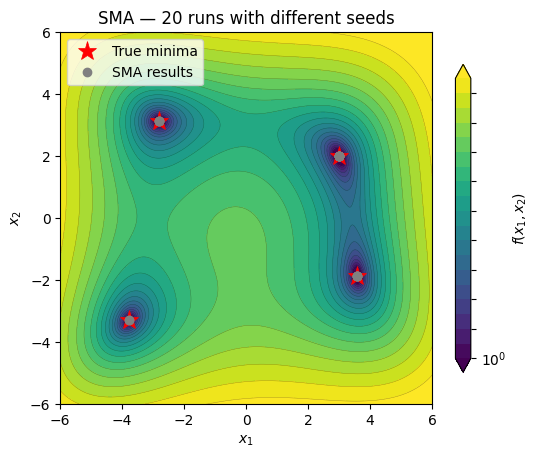

In [ ]:
fig_sma, ax_sma = plt.subplots(figsize=(6, 5))
plot_himmelblau_landscape(ax=ax_sma, title="SMA — 20 runs with different seeds")

ax_sma.plot(*himmelblau_minima.T, "r*", ms=14, mew=0.5, label="True minima", zorder=6)
ax_sma.plot(
    sma_multi_results[:, 0], sma_multi_results[:, 1],
    "o", ms=6, mew=1.0, color="0.5", mfc="0.5", label="SMA results", zorder=7,
)
ax_sma.legend(loc="upper left")
fig_sma

The grey circles cluster tightly around the known minima. SMA successfully discovers all four global minima across different random seeds — no prior knowledge of the landscape was needed.

## 6. Define Once, Solve Many Ways

This is CoFI's central value proposition. The **same problem definition** can be solved with any compatible tool. Let us compare three optimisation backends on the Himmelblau problem:

- **`scipy.optimize.minimize`** — gradient-based (L-BFGS-B)
- **`cofi.border_collie_optimization`** — an existing metaheuristic in CoFI
- **`mealpy.sma.demo.from.this.notebook`** — the tool we just built above

The problem definition does not change. Only `InversionOptions` differs.

In [ ]:
# ── Shared problem definition ──
# Note: bounds in per-parameter format for scipy compatibility
comparison_problem = BaseProblem()
comparison_problem.set_objective(himmelblau)
comparison_problem.set_gradient(himmelblau_gradient)
comparison_problem.set_model_shape((2,))
comparison_problem.set_bounds([(-6.0, 6.0), (-6.0, 6.0)])
comparison_problem.set_initial_model(np.array([0.0, 0.0]))

# ── Tool configurations ──
tool_configs = {
    "scipy.optimize.minimize": {},
    "cofi.border_collie_optimization": {"number_of_iterations": 200, "flock_size": 50, "seed": 0},
    "mealpy.sma.demo.from.this.notebook": {"epoch": 200, "pop_size": 50, "seed": 0},
}

comparison_results = {}
for _tool_name, _params in tool_configs.items():
    _opts = InversionOptions()
    _opts.set_solving_method("optimization")
    _opts.set_tool(_tool_name)
    if _params:
        _opts.set_params(**_params)

    _res = Inversion(comparison_problem, _opts).run()
    comparison_results[_tool_name] = _res.model
    print(f"{_tool_name:>40s}: [{_res.model[0]:7.4f}, {_res.model[1]:7.4f}]"
          f"  f = {himmelblau(_res.model):.2e}")

                 scipy.optimize.minimize: [ 3.0000,  2.0000]  f = 1.95e-17
         cofi.border_collie_optimization: [ 3.6016, -1.8089]  f = 4.25e-02
      mealpy.sma.demo.from.this.notebook: [ 3.5845, -1.8482]  f = 5.39e-08


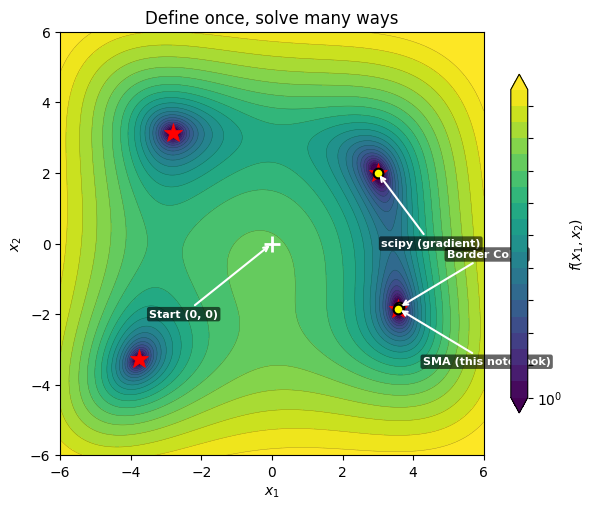

In [ ]:
fig_comp, ax_comp = plt.subplots(figsize=(7, 5.5))
plot_himmelblau_landscape(ax=ax_comp, title="Define once, solve many ways")

ax_comp.plot(*himmelblau_minima.T, "r*", ms=14, mew=0.5, zorder=6)

# Label map: short readable names for each tool
_labels = {
    "scipy.optimize.minimize": "scipy (gradient)",
    "cofi.border_collie_optimization": "Border Collie",
    "mealpy.sma.demo.from.this.notebook": "SMA (this notebook)",
}

# Arrow offsets (dx, dy) so labels don't overlap
# scipy→[3,2], BC→[-2.8,3.1], SMA→[-3.8,-3.3] with seed=0
_offsets = {
    "scipy.optimize.minimize": (1.5, -2.0),
    "cofi.border_collie_optimization": (2.5, 1.5),
    "mealpy.sma.demo.from.this.notebook": (2.5, -1.5),
}

for _tool_name, _model in comparison_results.items():
    ax_comp.plot(
        _model[0], _model[1],
        "ko", ms=7, mew=1.5, mfc="yellow", zorder=7,
    )
    ax_comp.annotate(
        _labels[_tool_name],
        xy=(_model[0], _model[1]),
        xytext=(_model[0] + _offsets[_tool_name][0],
                _model[1] + _offsets[_tool_name][1]),
        arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
        fontsize=8, fontweight="bold", color="white",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6, ec="none"),
        zorder=8,
    )

# Show the shared starting point
ax_comp.plot(0, 0, "w+", ms=12, mew=2, zorder=5)
ax_comp.annotate(
    "Start (0, 0)",
    xy=(0, 0),
    xytext=(-2.5, -2.0),
    arrowprops=dict(arrowstyle="->", color="white", lw=1.5),
    fontsize=8, fontweight="bold", color="white",
    ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6, ec="none"),
    zorder=8,
)

fig_comp

From the same starting point `(0, 0)`:
- **scipy** converges to the nearest minimum (gradient descent)
- **Border Collie** and **SMA** both explore more broadly, potentially finding different minima

The key insight: not a single line of the problem definition changed between the three runs. The user only switched the tool name. This is what contributing a solver to CoFI enables — every problem that has already been defined in CoFI can immediately benefit from the new algorithm. Note that the SMA result here comes from the tool we built in this notebook, not from the production `mealpy.sma` backend (though they would behave identically).

## 7. Testing Your Contribution

A pull request should include tests that verify the tool works correctly across a range of scenarios. Below are the essential test cases, demonstrated inline.

### Test 1: Basic optimisation

The simplest possible invocation: scalar objective, uniform bounds, no optional components. This confirms the tool is correctly wired into CoFI's dispatch pipeline and that `__call__` returns a result dict with `success=True` and a converged model.

In [ ]:
_p = BaseProblem()
_p.set_objective(himmelblau)
_p.set_model_shape((2,))
_p.set_bounds((-6.0, 6.0))

_o = InversionOptions()
_o.set_solving_method("optimization")
_o.set_tool("mealpy.sma.demo.from.this.notebook")
_o.set_params(epoch=100, pop_size=30, seed=0)

_r = Inversion(_p, _o).run()
assert _r.success, "Solver should report success"
assert himmelblau(_r.model) < 1e-4, "Should find a minimum"
print("Test 1 passed: basic optimisation")

Test 1 passed: basic optimisation


### Test 2: Tuple-returning objectives (gradient compatibility)

Many CoFI objectives return `(value, gradient)` tuples. The tool must handle this gracefully by extracting only the scalar value.

In [ ]:
def _himmelblau_with_grad(model):
    x1, x2 = model
    value = (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2
    return value, himmelblau_gradient(model)

_p = BaseProblem()
_p.set_objective(_himmelblau_with_grad)
_p.set_model_shape((2,))
_p.set_bounds((-6.0, 6.0))

_o = InversionOptions()
_o.set_solving_method("optimization")
_o.set_tool("mealpy.sma.demo.from.this.notebook")
_o.set_params(epoch=100, pop_size=30, seed=0)

_r = Inversion(_p, _o).run()
assert _r.success
assert _himmelblau_with_grad(_r.model)[0] < 1e-4
print("Test 2 passed: tuple-returning objective")

Test 2 passed: tuple-returning objective


### Test 3: Per-parameter bounds

CoFI supports two bounds formats: a uniform pair `(lb, ub)` and a per-parameter list `[(l1, u1), (l2, u2), ...]`. Test 1 used uniform bounds; this test exercises the per-parameter branch in `_setup_problem_dict` to confirm both formats are parsed correctly.

In [ ]:
_p = BaseProblem()
_p.set_objective(himmelblau)
_p.set_model_shape((2,))
_p.set_bounds([(-6.0, 6.0), (-6.0, 6.0)])  # per-parameter format

_o = InversionOptions()
_o.set_solving_method("optimization")
_o.set_tool("mealpy.sma.demo.from.this.notebook")
_o.set_params(epoch=100, pop_size=30, seed=0)

_r = Inversion(_p, _o).run()
assert _r.success
assert himmelblau(_r.model) < 1e-4
print("Test 3 passed: per-parameter bounds")

Test 3 passed: per-parameter bounds


### Test 4: Higher-dimensional problem (Rosenbrock 10D)

The Himmelblau tests use a 2D model. This test checks that the flat-vector/reshape round-trip in `_objective_function_wrapper` scales to larger `model_shape`. Exact convergence to `[1, …, 1]` is not asserted — Rosenbrock in 10D is a genuinely hard problem for metaheuristics — but the tool must complete without error and reduce the objective substantially.

In [ ]:
def rosenbrock_nd(model):
    return sum(100*(model[i+1] - model[i]**2)**2 + (1 - model[i])**2
               for i in range(len(model) - 1))

n_dim = 10
_p = BaseProblem()
_p.set_objective(rosenbrock_nd)
_p.set_model_shape((n_dim,))
_p.set_bounds((-5.0, 5.0))

_o = InversionOptions()
_o.set_solving_method("optimization")
_o.set_tool("mealpy.sma.demo.from.this.notebook")
_o.set_params(epoch=500, pop_size=100, seed=42)

_r = Inversion(_p, _o).run()
assert _r.success
# Rosenbrock minimum is at (1, 1, ..., 1); be lenient with 10D
print(f"Test 4: Rosenbrock 10D — f = {rosenbrock_nd(_r.model):.4f}")
print(f"  Model (first 5): {_r.model[:5].round(3)}")
print(f"  True minimum: [1, 1, ..., 1], f = 0")
print("Test 4 passed: higher-dimensional problem")

Test 4: Rosenbrock 10D — f = 5.4654
  Model (first 5): [0.865 0.749 0.564 0.324 0.111]
  True minimum: [1, 1, ..., 1], f = 0
Test 4 passed: higher-dimensional problem


### Test 5: Missing required component raises an error

Calling `super().__init__()` activates CoFI's automatic validation: if a component listed in `required_in_problem()` is missing, an error is raised before the solver runs. Here we deliberately omit `model_shape` to confirm that the user receives a clear error immediately, rather than a cryptic crash inside MEALPY.

In [ ]:
_p = BaseProblem()
_p.set_objective(himmelblau)
# Deliberately omit model_shape

_o = InversionOptions()
_o.set_solving_method("optimization")
_o.set_tool("mealpy.sma.demo.from.this.notebook")

try:
    Inversion(_p, _o).run()
    assert False, "Should have raised an error"
except Exception as e:
    print(f"Test 5 passed: missing model_shape raises error")
    print(f"  Error type: {type(e).__name__}")

Test 5 passed: missing model_shape raises error
  Error type: ValueError


## 8. Contribution Checklist

To contribute a new solver to CoFI, a pull request should include the following:

### Files to create

| File | Contents |
|------|----------|
| `src/cofi/tools/_mealpy_sma.py` | Tool class (`MealpySma`) subclassing `BaseInferenceTool` |
| `tests/cofi_tools/test_mealpy_sma.py` | Tests covering basic optimisation, bounds, tuple objectives, high-dimensional scaling, error handling |

### Files to modify

| File | Change |
|------|--------|
| `src/cofi/tools/__init__.py` | Import the class; add to `inference_tools_table` with aliases |
| `pyproject.toml` | Add optional dependency (`mealpy >= 3.0`) |

### Optional but recommended

| File | Contents |
|------|----------|
| `examples/slime_mould_algorithm_optimization.ipynb` | Example notebook in the `cofi-examples` repository demonstrating the tool on benchmark problems |

### Quality checklist

- [ ] `required_in_problem` / `optional_in_problem` are minimal and correct
- [ ] `__call__` returns a dict with at least `"model"` and `"success"`
- [ ] Tuple-returning objectives are handled (scalar extraction)
- [ ] Multiple bounds formats work (uniform, per-parameter)
- [ ] Dependencies are lazy-imported (inside methods, not at module top level)
- [ ] Tests pass with `pytest`
- [ ] Code formatted with `black`
- [ ] Test coverage > 80%

### Recommended commit strategy

```
feat: add MealpySma inference tool
feat: register mealpy.sma in inference_tools_table
chore: add mealpy optional dependency to pyproject.toml
test: add tests for MealpySma
style: format with black
```

## Summary

This notebook demonstrated the full workflow for contributing a new solver to CoFI:

1. **Motivation** — Gradient-based methods fall short on multimodal landscapes, motivating a population-based alternative
2. **The `BaseInferenceTool` contract** — The six members every solver must implement
3. **Implementation** — An SMA tool class built step by step, with each design decision explained
4. **Registration** — The tool registered at runtime and verified in CoFI's tool registry
5. **Validation** — The implementation tested on the Himmelblau function, confirming it finds all four global minima
6. **Define once, solve many ways** — Three solvers compared on the same problem with identical problem definitions
7. **Testing** — Edge cases covered: tuple objectives, per-parameter bounds, high-dimensional problems, and error handling
8. **Contribution checklist** — What a pull request should contain

In [ ]:
import sys as _sys
import importlib.metadata as _importlib_metadata
from datetime import datetime as _datetime

# Packages explicitly imported in this notebook
_packages = [
    "numpy",
    "scipy",
    "matplotlib",
    "mealpy",
    "cofi",
    "marimo",
]

_env_info = [{"Package": "Python", "Version": _sys.version.split()[0]}]
for pkg in _packages:
    try:
        ver = _importlib_metadata.version(pkg)
        _env_info.append({"Package": pkg, "Version": ver})
    except _importlib_metadata.PackageNotFoundError:
        pass

mo.vstack([
    mo.md(f"**Environment** — {_datetime.now().strftime('%Y-%m-%d %H:%M')}"),
    mo.ui.table(_env_info, selection=None, page_size=len(_env_info))
])

Environment — 2026-04-28 15:23 <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"Package\":\"Python\",\"Version\":\"3.14.3\"},{\"Package\":\"numpy\",\"Version\":\"2.4.4\"},{\"Package\":\"scipy\",\"Version\":\"1.17.1\"},{\"Package\":\"matplotlib\",\"Version\":\"3.10.9\"},{\"Package\":\"mealpy\",\"Version\":\"3.0.2\"},{\"Package\":\"cofi\",\"Version\":\"0.2.11+52.gbe767ff\"},{\"Package\":\"marimo\",\"Version\":\"0.23.3\"}]"' data-total-rows='7' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='7' data-show-filters='false' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>